# Tutorial 7: PPI Graph-Neural-Network Embeddings

> **⚠️ Verification Notice**: This tutorial is under active development and
> **still needs verification** against production STRING-db data. The PPI-GNN
> pipeline (graph construction, GNN training, embedding extraction) has been
> implemented but **has not been fully validated** on large-scale networks.
> Results shown here are illustrative and may change as the implementation
> matures. Please report any issues you encounter.

This notebook demonstrates how to generate **gene embeddings from
protein-protein interaction (PPI) networks** using a Graph Neural Network
(GNN) trained on the [STRING](https://string-db.org/) database.

Unlike sequence-based models (ESM2, Enformer, …), PPI-GNN embeddings
capture **functional relationships** between genes: two genes that share
many interaction partners will have similar embeddings, even if their
sequences are unrelated.

### Architecture

```
STRING PPI network ──► Graph (nodes=genes, edges=interactions)
                              │
                     GNN Encoder (GCN / GraphSAGE / GAT)
                              │
                     Self-supervised link-prediction training
                              │
                              ▼
                     Gene embeddings (n_genes × output_dim)
```

**Requirements**: `torch-geometric` must be installed:
```bash
pip install torch-geometric
```

In [1]:
import logging
logging.basicConfig(level=logging.INFO)

In [2]:
import torch
import numpy as np

from embpy.models.ppi_models import PPIGNNWrapper

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

INFO:rdkit:Enabling RDKit 2025.09.5 jupyter extensions


Device: cuda


## 1. Build the PPI graph

There are three ways to provide the interaction data:

| Method | When to use |
|---|---|
| `gene_ids=[...]` | Small gene sets — fetches from STRING API |
| `string_links_file="..."` | Full species network from [STRING downloads](https://string-db.org/cgi/download) |
| `interactions_df=df` | Pre-loaded DataFrame with `protein1`, `protein2`, `combined_score` |

### 1.1 From a list of gene symbols (STRING API)

In [3]:
# Define a set of cancer-related genes
cancer_genes = [
    "TP53", "BRCA1", "BRCA2", "EGFR", "KRAS", "MYC",
    "PTEN", "RB1", "AKT1", "PIK3CA", "BRAF", "NRAS",
    "CDH1", "APC", "SMAD4", "VHL", "WT1", "RET",
    "ALK", "ERBB2", "FGFR1", "FGFR2", "IDH1", "JAK2",
    "KIT", "MET", "PDGFRA", "RAF1", "SRC", "ABL1",
]

print(f"{len(cancer_genes)} genes to embed")

30 genes to embed


In [4]:
wrapper = PPIGNNWrapper(
    gnn_type="gcn",          # Graph Convolutional Network
    input_dim=128,            # learnable initial node features
    hidden_dim=256,           # GNN hidden layer width
    output_dim=128,           # final embedding dimension
    num_layers=3,             # 3-layer GNN
    dropout=0.2,
    species=9606,             # human
    score_threshold=400,      # STRING combined score threshold
)
wrapper.load(device)

# Fetch interactions from STRING and build the graph
wrapper.build_graph(gene_ids=cancer_genes)

print(f"Graph: {wrapper.num_nodes} nodes, {wrapper.num_edges} directed edges")
print(f"Genes in graph: {wrapper.graph_genes[:10]}...")

INFO:root:No pre-trained PPI GNN checkpoint found. Call build_graph() then train_embeddings() before embedding.
INFO:root:Built PPI graph: 30 nodes, 670 directed edges, species=9606


Graph: 30 nodes, 670 directed edges
Genes in graph: ['ABL1', 'AKT1', 'ALK', 'APC', 'BRAF', 'BRCA1', 'BRCA2', 'CDH1', 'EGFR', 'ERBB2']...


### 1.2 From a local STRING file (alternative)

For genome-wide embeddings, download the full species network from
[string-db.org/cgi/download](https://string-db.org/cgi/download) and
load it directly:

```python
# wrapper.build_graph(string_links_file="9606.protein.links.v12.0.txt")
```

### 1.3 From a custom DataFrame

```python
import pandas as pd
df = pd.DataFrame({
    "protein1": ["TP53", "BRCA1"],
    "protein2": ["BRCA1", "EGFR"],
    "combined_score": [950, 800],
})
wrapper.build_graph(interactions_df=df)
```

## 2. Train the GNN

The GNN is trained with **self-supervised link prediction**: it learns to
distinguish real STRING edges from random (negative) edges. No labels are
needed.

In [5]:
losses = wrapper.train_embeddings(
    epochs=200,
    lr=0.01,
    log_every=50,
)

print(f"\nFinal loss: {losses[-1]:.4f}")

INFO:root:Epoch 50/200  loss=0.4461
INFO:root:Epoch 100/200  loss=0.4127
INFO:root:Epoch 150/200  loss=0.3991
INFO:root:Epoch 200/200  loss=0.4005
INFO:root:Training complete. Final loss: 0.4005



Final loss: 0.4005


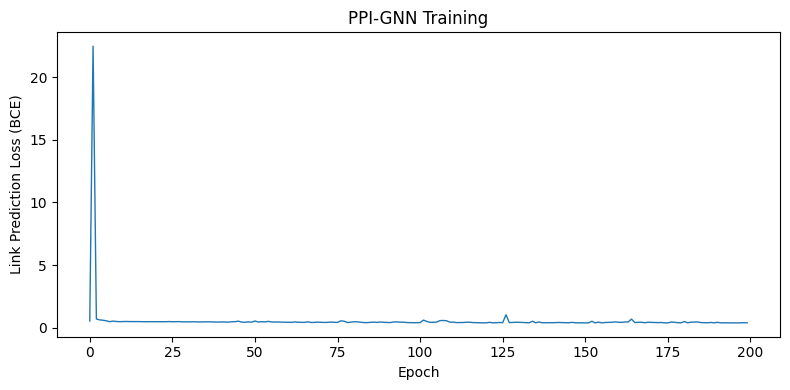

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(losses, linewidth=1)
ax.set_xlabel("Epoch")
ax.set_ylabel("Link Prediction Loss (BCE)")
ax.set_title("PPI-GNN Training")
plt.tight_layout()
plt.show()

## 3. Generate gene embeddings

In [7]:
# Single gene
emb_tp53 = wrapper.embed("TP53")
print(f"TP53 embedding: shape={emb_tp53.shape}, dtype={emb_tp53.dtype}")
print(f"First 10 dims: {emb_tp53[:10]}")

TP53 embedding: shape=(128,), dtype=float32
First 10 dims: [ 0.03195614 -0.00812024 -0.2303794   0.00735452  0.02522365  0.0481778
 -0.11946802  0.17362863 -0.09084007 -0.25342196]


In [8]:
# Batch embedding
query_genes = ["TP53", "BRCA1", "EGFR", "KRAS", "MYC"]
embs = wrapper.embed_batch(query_genes)

for gene, emb in zip(query_genes, embs):
    print(f"  {gene:8s} → dim {emb.shape[0]}, L2={np.linalg.norm(emb):.2f}")

  TP53     → dim 128, L2=1.84
  BRCA1    → dim 128, L2=1.67
  EGFR     → dim 128, L2=1.83
  KRAS     → dim 128, L2=1.83
  MYC      → dim 128, L2=1.84


## 4. Explore PPI similarity

Genes with similar interaction profiles should have high cosine similarity.

In [9]:
from numpy.linalg import norm

def cosine_sim(a, b):
    return np.dot(a, b) / (norm(a) * norm(b) + 1e-8)

# Build a similarity matrix
genes = wrapper.graph_genes
all_embs = np.stack([wrapper.embed(g) for g in genes])

# Normalise
norms = np.linalg.norm(all_embs, axis=1, keepdims=True) + 1e-8
all_embs_norm = all_embs / norms
sim_matrix = all_embs_norm @ all_embs_norm.T

print(f"Similarity matrix shape: {sim_matrix.shape}")

Similarity matrix shape: (30, 30)


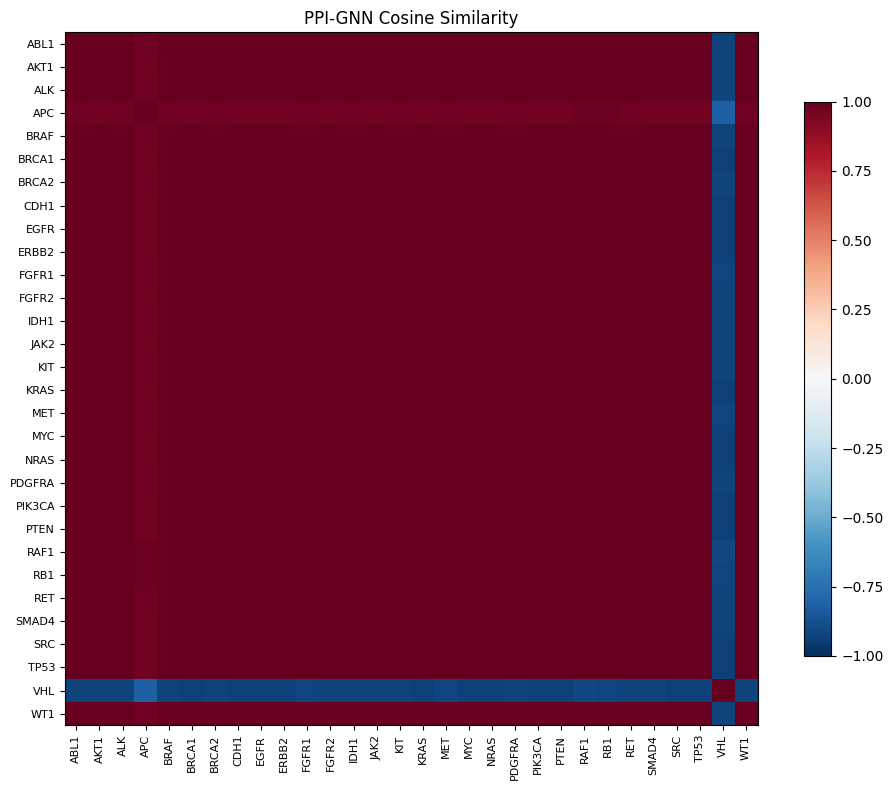

In [10]:
# Visualise the similarity matrix
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(sim_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(genes)))
ax.set_yticks(range(len(genes)))
ax.set_xticklabels(genes, rotation=90, fontsize=8)
ax.set_yticklabels(genes, fontsize=8)
ax.set_title("PPI-GNN Cosine Similarity")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 5. 2D visualisation with PCA

In [ ]:
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2).fit_transform(all_embs)

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(pca_2d[:, 0], pca_2d[:, 1], s=80, alpha=0.8, edgecolors="k", linewidth=0.5)

for i, gene in enumerate(genes):
    ax.annotate(gene, (pca_2d[i, 0], pca_2d[i, 1]),
                fontsize=8, ha="left", va="bottom")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PPI-GNN Gene Embeddings (PCA)")
plt.tight_layout()
plt.show()

## 6. Compare GNN architectures

The `PPIGNNWrapper` supports three GNN architectures:

| `gnn_type` | Architecture | Notes |
|---|---|---|
| `"gcn"` | Graph Convolutional Network | Fast, good default |
| `"sage"` | GraphSAGE | Inductive, samples neighbourhoods |
| `"gat"` | Graph Attention Network | Attention-weighted aggregation |

In [ ]:
# Compare training curves across architectures
# (using the same graph already fetched)
import pandas as pd

# Get the interactions_df from our existing wrapper's graph
# (rebuild from the same node set for fair comparison)
results = {}

for arch in ["gcn", "sage", "gat"]:
    w = PPIGNNWrapper(
        gnn_type=arch,
        input_dim=64, hidden_dim=128, output_dim=64,
        num_layers=3, dropout=0.2,
        species=9606, score_threshold=400,
    )
    w.load(device)
    w.build_graph(gene_ids=cancer_genes)
    losses = w.train_embeddings(epochs=100, lr=0.01, log_every=200)
    results[arch] = losses
    print(f"  {arch:5s} → final loss {losses[-1]:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
for arch, losses in results.items():
    ax.plot(losses, label=arch, linewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("GNN Architecture Comparison")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Save and reload trained model

Training on large graphs can be slow, so you can save the checkpoint
and reload it later.

In [ ]:
import tempfile, os

with tempfile.TemporaryDirectory() as tmpdir:
    ckpt_path = os.path.join(tmpdir, "ppi_gnn.pt")

    # Save
    wrapper.save_checkpoint(ckpt_path)
    print(f"Saved checkpoint: {os.path.getsize(ckpt_path):,} bytes")

    # Load into a fresh wrapper
    loaded = PPIGNNWrapper(model_path_or_name=ckpt_path)
    loaded.load(device)

    emb_original = wrapper.embed("TP53")
    emb_loaded = loaded.embed("TP53")
    print(f"Embeddings match: {np.allclose(emb_original, emb_loaded)}")

## 8. Combining PPI embeddings with sequence embeddings

PPI-GNN embeddings capture **functional context** while sequence models
(ESM2, Enformer) capture **molecular properties**. You can combine both
using the same PCA + combine workflow from
[Tutorial 6](06_combined_analysis.ipynb).

In [ ]:
import anndata as ad

# Build an AnnData from PPI embeddings
genes = wrapper.graph_genes
ppi_matrix = np.stack([wrapper.embed(g) for g in genes]).astype(np.float32)

adata_ppi = ad.AnnData(
    obs=pd.DataFrame({"gene": genes}, index=[str(i) for i in range(len(genes))]),
)
adata_ppi.obsm["X_ppi_gnn"] = ppi_matrix

print(adata_ppi)
print(f"PPI embedding matrix: {adata_ppi.obsm['X_ppi_gnn'].shape}")

In [ ]:
# Reduce with PCA (same workflow as Tutorial 6)
from embpy.pp.basic import reduce_embeddings

adata_ppi = reduce_embeddings(
    adata_ppi,
    obsm_key="X_ppi_gnn",
    n_components=50,
    scale=True,
)

print(f"Reduced PPI embeddings: {adata_ppi.obsm['X_ppi_gnn_pca'].shape}")

## Summary

| Step | Code |
|---|---|
| Create wrapper | `PPIGNNWrapper(gnn_type="gcn", output_dim=128)` |
| Build graph (API) | `wrapper.build_graph(gene_ids=[...])` |
| Build graph (file) | `wrapper.build_graph(string_links_file="...")` |
| Train | `wrapper.train_embeddings(epochs=200)` |
| Embed single gene | `wrapper.embed("TP53")` |
| Embed batch | `wrapper.embed_batch(["TP53", "BRCA1"])` |
| Save / load | `wrapper.save_checkpoint(path)` / `PPIGNNWrapper(model_path_or_name=path)` |
| Available architectures | `"gcn"`, `"sage"`, `"gat"` |